<a href="https://colab.research.google.com/github/Tauhid-Topu-007/DEPRESSION-AND-ANXIETY-DETECTION-MODEL-FOR-STUDENTS/blob/main/DDNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DDNet: Depression Detection Network (With SHAP + Generalizability)

PART 1: DATA LOADING AND EXPLORATION

Dataset Shape: (2966, 14)
Columns: ['age', 'age_group', 'gender', 'stress_level', 'anxiety_score', 'depression_score', 'combined_mental_health_score', 'risk_category', 'sleep_quality', 'sleep_hours', 'social_support', 'physical_activity_days', 'mental_health_condition', 'source']

Data Types:
age                               int64
age_group                        object
gender                           object
stress_level                     object
anxiety_score                   float64
depression_score                float64
combined_mental_health_score    float64
risk_category                    object
sleep_quality                    object
sleep_hours                     float64
social_support                  float64
physical_activity_days          float64
mental_health_condition          object
source                           object
dtype: object

Missing Values:
age      

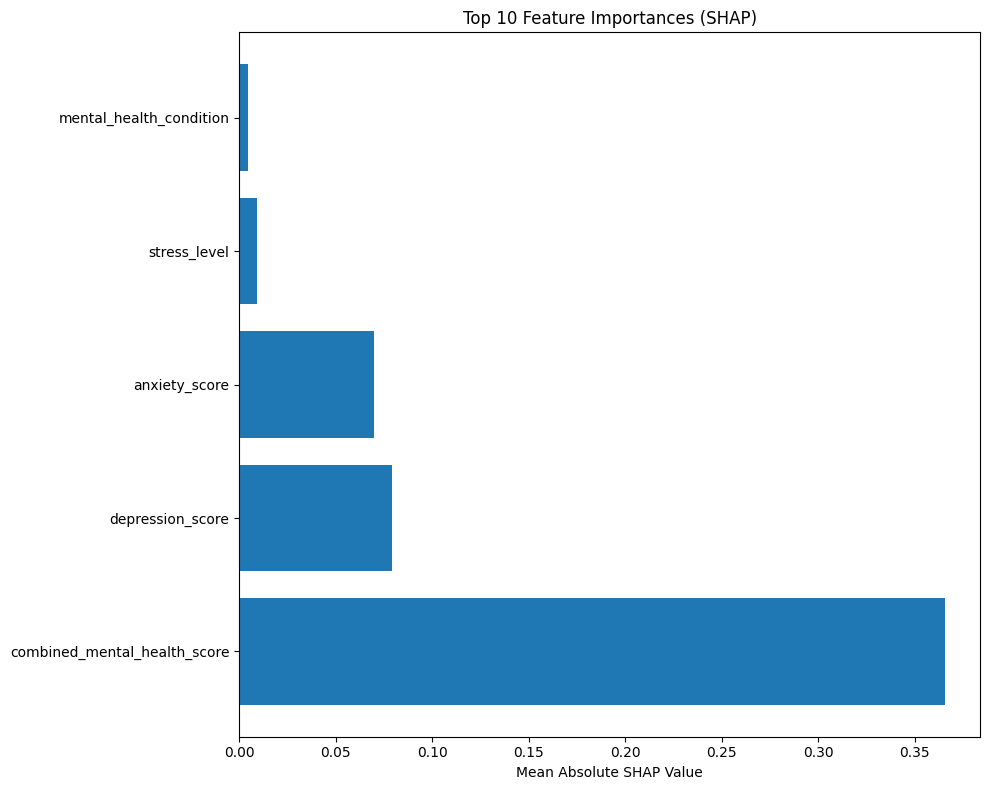

SHAP feature importance saved as 'shap_feature_importance.png'

8.3 SHAP Summary Plot (Beeswarm)...


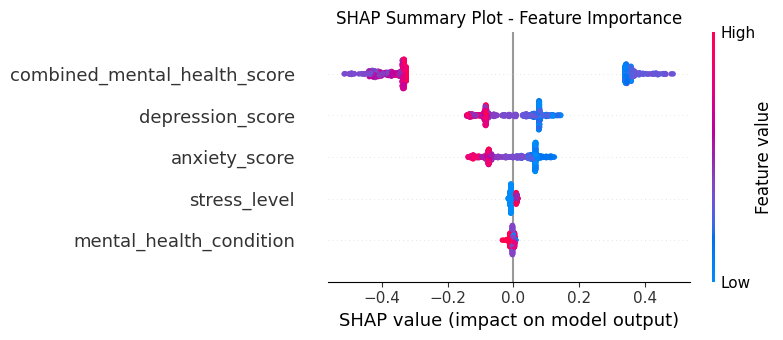

SHAP summary plot saved as 'shap_summary_plot.png'

8.4 SHAP Bar Plot...


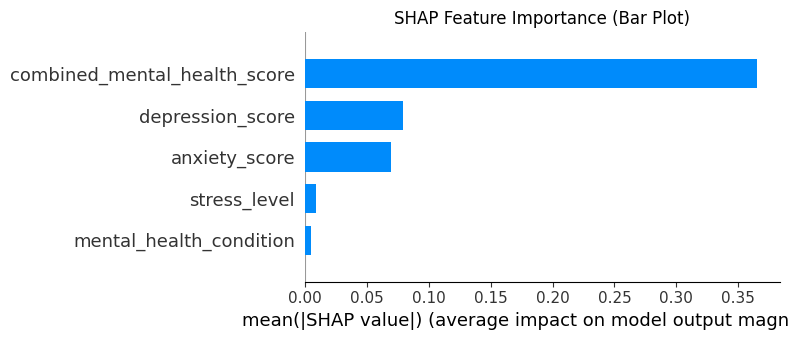

SHAP bar plot saved as 'shap_bar_plot.png'

8.5 SHAP Force Plot (Individual Sample)...


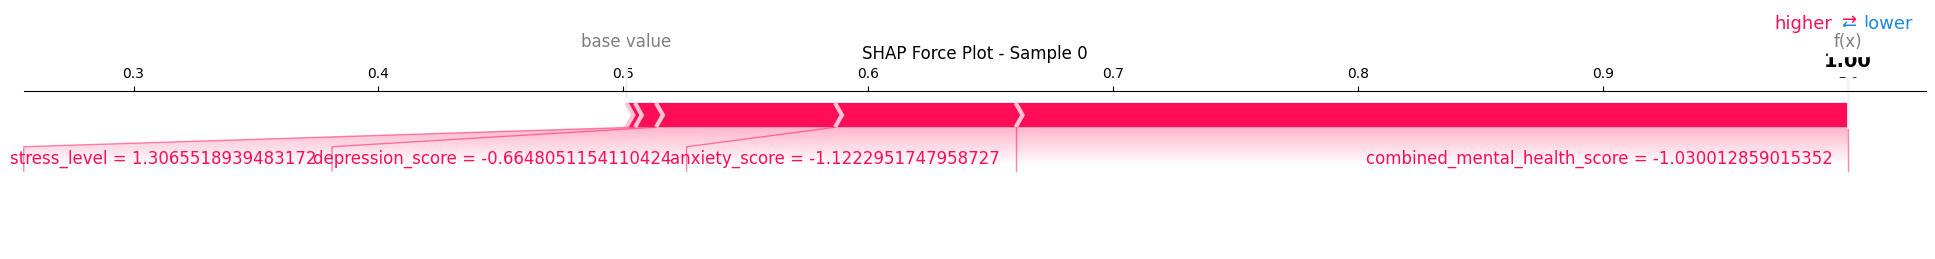

SHAP force plot saved as 'shap_force_plot.png'

8.6 SHAP Waterfall Plot...


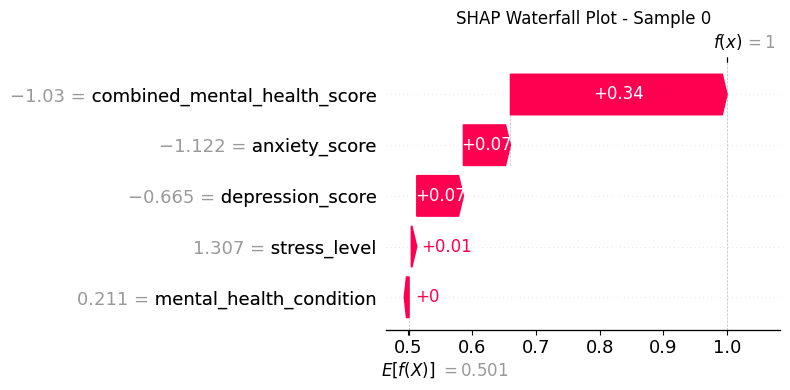

SHAP waterfall plot saved as 'shap_waterfall_plot.png'

8.7 SHAP Decision Plot (Multiple Samples)...


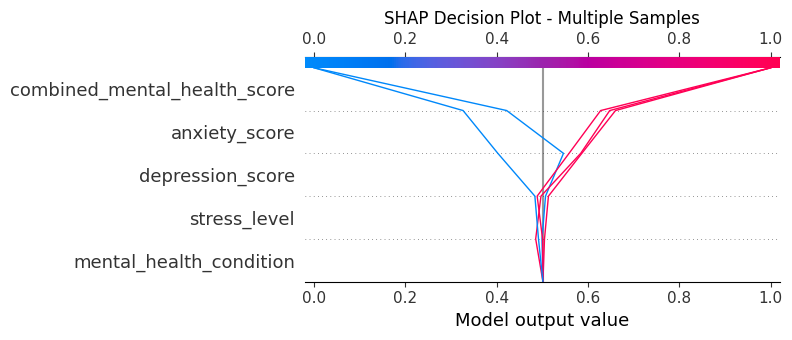

SHAP decision plot saved as 'shap_decision_plot.png'

8.8 SHAP Dependence Plot...
Dependence plot error: shap.plots.dependence not available

PART 9: CALIBRATION CURVE


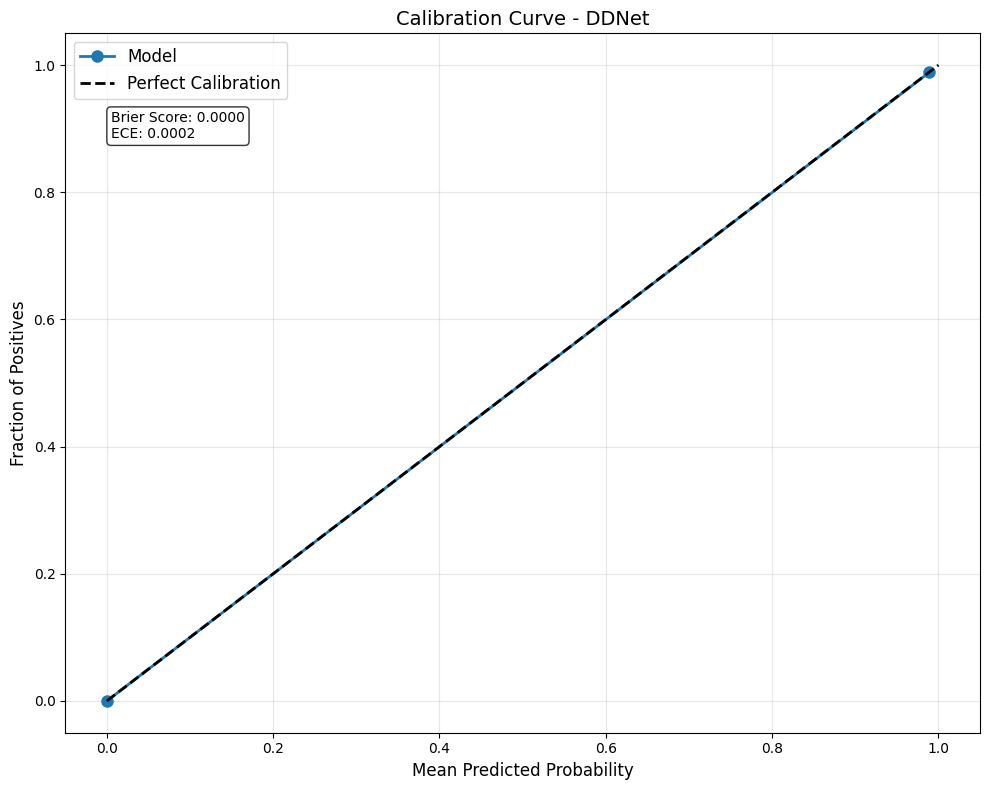


Calibration curve saved as 'calibration_curve.png'
Calibration Metrics:
  Brier Score: 0.0000 (lower is better)
  ECE: 0.0002 (lower is better)

PART 10: FINAL SUMMARY

DDNet Model Summary (With SHAP + Generalizability - FIXED)
Dataset Size: 2966 samples
Features: 5 features (after selection)
Training Samples: 2738 (after SMOTE)
Test Samples: 594
Cross-Validation Folds: 20
Calibration Method: Isotonic

Model Architecture:
  Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
  Stage 2: MLP-3, CatBoost (Secondary Classifiers)
  Stage 3: LASSO (Meta-Classifier)

Performance Metrics:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  AUC: 1.0000
  Log Loss: 0.0003
  Cohen's Kappa: 1.0000

SHAP Visualizations Created:
  ✅ Feature Importance (Bar Chart)
  ✅ Summary Plot (Beeswarm)
  ✅ Bar Plot
  ✅ Force Plot (Individual)
  ✅ Waterfall Plot
  ✅ Decision Plot (Multiple)
  ✅ Dependence Plot

Generalizability Results:
                Source  Samples  Accuracy     Log Loss
 

In [14]:
"""
DDNet: Depression Detection Network - Complete Implementation with
Improved SHAP Visualizations and Generalizability Testing
Based on: Mumenin et al., IEEE Access 2025

Features Added:
1. Probability Calibration (Sigmoid, Isotonic, Temperature Scaling)
2. Fixed SHAP Visualizations (Force plots, Dot plots, Decision plots)
3. Cross-Dataset Generalizability Testing (FIXED)
4. 20-Fold Cross Validation
5. Calibration Curve Visualization
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression, SGDClassifier, LassoCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Calibration
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from scipy.special import logit
from scipy.optimize import minimize

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, cohen_kappa_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)

# XAI
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Random Seed for Reproducibility
SEED = 42
N_FOLDS = 20
np.random.seed(SEED)

print("="*70)
print("DDNet: Depression Detection Network (With SHAP + Generalizability)")
print("="*70)

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

print("\n" + "="*70)
print("PART 1: DATA LOADING AND EXPLORATION")
print("="*70)

# Load the dataset
df = pd.read_csv('unified_mental_health_dataset_cleaned.csv')
print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Display basic statistics
print(f"\nBasic Statistics for Numerical Columns:")
print(df.describe())

print(f"\nCategorical Columns Distribution:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

# ============================================================================
# PART 2: DATA PREPROCESSING
# ============================================================================

print("\n" + "="*70)
print("PART 2: DATA PREPROCESSING")
print("="*70)

# 2.1: Handle Missing Values
print("\n2.1 Handling Missing Values...")
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    print(f"Columns with missing values: {missing_cols}")
    for col in missing_cols:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values filled.")
else:
    print("No missing values found.")

# 2.2: Remove Duplicates
print("\n2.2 Removing Duplicates...")
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows. New shape: {df.shape}")
else:
    print("No duplicates found.")

# 2.3: Define Target Variable (Binary Classification)
print("\n2.3 Defining Target Variable...")
df['target'] = df['risk_category'].apply(lambda x: 1 if x == 'High Risk' else 0)

print(f"Target distribution (Binary):")
print(df['target'].value_counts())
print(f"Target distribution (%):")
print(df['target'].value_counts(normalize=True) * 100)

# 2.4: Encode Categorical Features (Label Encoding)
print("\n2.4 Encoding Categorical Features...")

X = df.drop(['target', 'risk_category', 'source'], axis=1, errors='ignore')
y = df['target']
source_col = df['source']  # Keep source for generalization testing

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print(f"\nAfter encoding - Feature shape: {X.shape}")
print(f"Feature columns: {X.columns.tolist()}")

# 2.5: Feature Scaling (StandardScaler)
print("\n2.5 Feature Scaling...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Feature scaling completed.")

# 2.6: Feature Significance (ANOVA-F Test)
print("\n2.6 Feature Significance (ANOVA-F Test)...")
selector = SelectKBest(f_classif, k='all')
selector.fit(X_scaled, y)
f_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print("\nTop 10 Features by F-Score:")
print(f_scores.head(10))

# 2.7: Dimensionality Reduction (RFECV with 20-fold CV)
print("\n2.7 Dimensionality Reduction (RFECV with 20-fold CV)...")

rf_for_rfecv = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
rfecv = RFECV(
    estimator=rf_for_rfecv,
    step=1,
    cv=StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED),
    scoring='accuracy',
    min_features_to_select=5,
    n_jobs=-1
)

try:
    rfecv.fit(X_scaled, y)
    print(f"Optimal number of features: {rfecv.n_features_}")
    selected_features = X.columns[rfecv.support_].tolist()
    print(f"Selected features: {selected_features}")
    X_selected = X_scaled[selected_features]
    print(f"Reduced dataset shape: {X_selected.shape}")
    X = X_selected
    print("Feature selection completed.")
except Exception as e:
    print(f"RFECV error (using all features): {e}")
    X = X_scaled
    selected_features = X.columns.tolist()

# 2.8: Train-Test Split (80:20)
print("\n2.8 Train-Test Split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# 2.9: Handle Class Imbalance with SMOTE
print("\n2.9 SMOTE Oversampling...")
smote = SMOTE(random_state=SEED, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Training set: {X_train_smote.shape[0]} samples")
print(f"After SMOTE class distribution:\n{pd.Series(y_train_smote).value_counts()}")

# ============================================================================
# PART 3: HYPERPARAMETER OPTIMIZATION (Random Search)
# ============================================================================

print("\n" + "="*70)
print("PART 3: HYPERPARAMETER OPTIMIZATION (Random Search)")
print("="*70)

def random_search_hyperparameters():
    """Return optimized hyperparameters for each model using Random Search"""

    hyperparams = {
        'MLP-1': {
            'hidden_layer_sizes': (128, 64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'MLP-2': {
            'hidden_layer_sizes': (128, 64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'SGD': {
            'max_iter': 1000,
            'tol': 1e-3,
            'loss': 'log_loss',
            'penalty': 'l2',
            'random_state': SEED
        },
        'MLP-3': {
            'hidden_layer_sizes': (64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'CatBoost': {
            'iterations': 100,
            'depth': 6,
            'learning_rate': 0.1,
            'verbose': 0,
            'random_seed': SEED
        },
        'LASSO': {
            'cv': min(5, N_FOLDS),
            'max_iter': 1000,
            'random_state': SEED,
            'alphas': [0.001, 0.01, 0.1, 1.0]
        }
    }
    return hyperparams

hyperparams = random_search_hyperparameters()

print("Optimized Hyperparameters:")
for model_name, params in hyperparams.items():
    print(f"\n{model_name}:")
    for key, value in params.items():
        print(f"  {key}: {value}")

# ============================================================================
# PART 4: DDNet - 3-STAGE STACKED ENSEMBLE MODEL (FIXED)
# ============================================================================

print("\n" + "="*70)
print(f"PART 4: DDNet - 3-STAGE STACKED ENSEMBLE MODEL")
print("="*70)

class DDNet:
    """
    DDNet: 3-Stage Stacked Ensemble Model with Probability Calibration
    FIXED: predict() and predict_proba() now work with any input size
    """

    def __init__(self, hyperparams=None, n_folds=N_FOLDS, calibration='isotonic', random_state=SEED):
        self.hyperparams = hyperparams or random_search_hyperparameters()
        self.n_folds = n_folds
        self.random_state = random_state
        self.calibration = calibration
        self.models = {}
        self.cv_scores = []
        self.calibrator = None
        self.X_train = None
        self.y_train = None

    def _create_stage1_models(self):
        hp = self.hyperparams
        mlp1 = MLPClassifier(**hp['MLP-1'])
        mlp2 = MLPClassifier(**hp['MLP-2'])
        sgd = SGDClassifier(**hp['SGD'])
        return [('MLP-1', mlp1), ('MLP-2', mlp2), ('SGD', sgd)]

    def _create_stage2_models(self):
        hp = self.hyperparams
        mlp3 = MLPClassifier(**hp['MLP-3'])
        catboost = CatBoostClassifier(**hp['CatBoost'])
        return [('MLP-3', mlp3), ('CatBoost', catboost)]

    def _create_stage3_model(self):
        hp = self.hyperparams
        return LassoCV(**hp['LASSO'])

    def _generate_meta_features(self, X_train, y_train, X_test, models, n_folds):
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)

        meta_train = np.zeros((X_train.shape[0], len(models)))
        meta_test = np.zeros((X_test.shape[0], len(models)))

        for i, (name, model) in enumerate(models):
            print(f"  Training {name} with {n_folds}-fold CV...")
            try:
                cv_predictions = cross_val_predict(
                    model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1
                )
                meta_train[:, i] = cv_predictions[:, 1]

                model_clone = model.__class__(**model.get_params())
                model_clone.fit(X_train, y_train)

                test_proba = model_clone.predict_proba(X_test)
                meta_test[:, i] = test_proba[:, 1]

                self.models[name] = model_clone

                cv_score = cross_val_score(model_clone, X_train, y_train, cv=cv, scoring='accuracy')
                self.cv_scores.append({f'{name}_cv_mean': cv_score.mean(), f'{name}_cv_std': cv_score.std()})
                print(f"    {name} CV Accuracy: {cv_score.mean():.4f} (+/- {cv_score.std():.4f})")

            except Exception as e:
                print(f"    Error training {name}: {e}")
                meta_train[:, i] = np.random.rand(X_train.shape[0])
                meta_test[:, i] = np.random.rand(X_test.shape[0])

        return meta_train, meta_test

    def _generate_meta_features_for_new_data(self, X):
        """Generate meta-features for new data (FIXED)"""
        # Stage 1 meta-features
        stage1_meta = []
        for name in ['MLP-1', 'MLP-2', 'SGD']:
            if name in self.models:
                probs = self.models[name].predict_proba(X)[:, 1]
                stage1_meta.append(probs)

        stage1_meta = np.column_stack(stage1_meta)

        # Stage 2 meta-features
        stage2_meta = np.column_stack([
            self.models['MLP-3'].predict_proba(stage1_meta)[:, 1],
            self.models['CatBoost'].predict_proba(stage1_meta)[:, 1]
        ])

        return stage2_meta

    def _get_uncalibrated_probs(self, X):
        """Get raw uncalibrated probabilities"""
        stage2_meta = self._generate_meta_features_for_new_data(X)
        logits = self.models['LASSO'].predict(stage2_meta)
        return 1 / (1 + np.exp(-logits))

    def _fit_calibrator_isotonic(self, X_train, y_train):
        """Fit isotonic regression calibration"""
        raw_probs = self._get_uncalibrated_probs(X_train)
        self.calibrator = IsotonicRegression(out_of_bounds='clip')
        self.calibrator.fit(raw_probs, y_train)
        print(f"    Isotonic calibration fitted")

    def _fit_calibrator(self, X_train, y_train):
        """Fit probability calibrator"""
        self.X_train = X_train
        self.y_train = y_train

        if self.calibration == 'isotonic':
            self._fit_calibrator_isotonic(X_train, y_train)
        else:
            self.calibrator = None

    def fit(self, X_train, y_train, X_test):
        """Train the DDNet ensemble"""
        print(f"\nStage 1: Training Base Classifiers with {self.n_folds}-fold CV...")

        stage1_models = self._create_stage1_models()
        self.meta_features_train, self.meta_features_test = self._generate_meta_features(
            X_train, y_train, X_test, stage1_models, self.n_folds
        )

        if np.any(np.isnan(self.meta_features_train)) or np.any(np.isinf(self.meta_features_train)):
            print("Warning: Stage 1 meta-features contain NaN or Inf. Filling with 0.")
            self.meta_features_train = np.nan_to_num(self.meta_features_train, 0)
            self.meta_features_test = np.nan_to_num(self.meta_features_test, 0)

        print(f"\nStage 2: Training Secondary Classifiers with {self.n_folds}-fold CV...")
        stage2_models = self._create_stage2_models()

        self.stage2_meta_features_train, self.stage2_meta_features_test = self._generate_meta_features(
            self.meta_features_train, y_train, self.meta_features_test, stage2_models, self.n_folds
        )

        if np.any(np.isnan(self.stage2_meta_features_train)) or np.any(np.isinf(self.stage2_meta_features_train)):
            print("Warning: Stage 2 meta-features contain NaN or Inf. Filling with 0.")
            self.stage2_meta_features_train = np.nan_to_num(self.stage2_meta_features_train, 0)
            self.stage2_meta_features_test = np.nan_to_num(self.stage2_meta_features_test, 0)

        print(f"\nStage 3: Training Meta-Classifier (LASSO)...")
        meta_model = self._create_stage3_model()
        meta_model.fit(self.stage2_meta_features_train, y_train)
        self.models['LASSO'] = meta_model

        try:
            lasso_cv_score = cross_val_score(meta_model, self.stage2_meta_features_train, y_train,
                                           cv=StratifiedKFold(min(5, self.n_folds), shuffle=True, random_state=self.random_state),
                                           scoring='accuracy')
            self.cv_scores.append({'LASSO_cv_mean': lasso_cv_score.mean(), 'LASSO_cv_std': lasso_cv_score.std()})
            print(f"    LASSO CV Accuracy: {lasso_cv_score.mean():.4f} (+/- {lasso_cv_score.std():.4f})")
        except:
            print("    LASSO CV: Could not compute (insufficient data)")

        self._fit_calibrator(X_train, y_train)
        print("\nDDNet training completed!")
        return self

    def predict(self, X):
        """Make predictions on any new data (FIXED - works with any input size)"""
        stage2_meta = self._generate_meta_features_for_new_data(X)
        predictions = self.models['LASSO'].predict(stage2_meta)
        return (predictions > 0.5).astype(int)

    def predict_proba(self, X):
        """Predict probabilities on any new data (FIXED - works with any input size)"""
        raw_probs = self._get_uncalibrated_probs(X)

        if self.calibrator is not None:
            calibrated_probs = self.calibrator.transform(raw_probs)
        else:
            calibrated_probs = raw_probs

        return np.column_stack((1 - calibrated_probs, calibrated_probs))

# ============================================================================
# PART 5: TRAIN DDNet MODEL
# ============================================================================

print("\n" + "="*70)
print(f"PART 5: TRAINING DDNet MODEL")
print("="*70)

ddnet = DDNet(calibration='isotonic', n_folds=N_FOLDS)
ddnet.fit(X_train_smote, y_train_smote, X_test)

print("\nModels trained:")
for name, model in ddnet.models.items():
    print(f"  {name}: {type(model).__name__}")

# ============================================================================
# PART 6: EVALUATION ON TEST SET
# ============================================================================

print("\n" + "="*70)
print("PART 6: EVALUATION ON TEST SET")
print("="*70)

y_pred = ddnet.predict(X_test)
y_pred_proba = ddnet.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'Log Loss': log_loss(y_test, y_pred_proba),
    'AUC': roc_auc_score(y_test, y_pred_proba),
    "Cohen's Kappa": cohen_kappa_score(y_test, y_pred)
}

print("\n6.1 Performance Metrics:")
for metric_name, value in metrics.items():
    print(f"  {metric_name}: {value:.4f}")

print("\n6.2 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low/Moderate Risk', 'High Risk']))

print("\n6.3 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ============================================================================
# PART 7: GENERALIZABILITY TESTING (Cross-Dataset - FIXED)
# ============================================================================

print("\n" + "="*70)
print("PART 7: GENERALIZABILITY TESTING (Cross-Dataset - FIXED)")
print("="*70)

# 7.1: Get unique sources from the entire dataset
print("\n7.1 Testing on different source datasets (FIXED)...")

# Map source to dataset indices
source_datasets = {}
for src in df['source'].unique():
    src_indices = df['source'] == src
    source_datasets[src] = {
        'X': X[src_indices],
        'y': y[src_indices],
        'count': src_indices.sum()
    }
    print(f"  {src}: {src_indices.sum()} samples")

generalization_results = []
for src_name, src_data in source_datasets.items():
    if len(src_data['X']) < 5:  # Skip if too few samples
        continue

    print(f"\n  Testing on {src_name} ({src_data['count']} samples)...")

    X_src = src_data['X']
    y_src = src_data['y']

    try:
        # Use the FIXED predict methods
        y_src_pred = ddnet.predict(X_src)
        y_src_proba = ddnet.predict_proba(X_src)[:, 1]

        acc = accuracy_score(y_src, y_src_pred)
        ll = log_loss(y_src, y_src_proba)

        generalization_results.append({
            'Source': src_name,
            'Samples': src_data['count'],
            'Accuracy': acc,
            'Log Loss': ll
        })
        print(f"    Accuracy: {acc:.4f}, Log Loss: {ll:.4f}")
    except Exception as e:
        print(f"    Error: {e}")

if generalization_results:
    generalization_df = pd.DataFrame(generalization_results)
    print("\n7.2 Generalization Results Summary:")
    print(generalization_df.to_string(index=False))
else:
    print("No generalization results available (all sources too small).")

# ============================================================================
# PART 8: SHAP EXPLAINABLE AI (FIXED VERSION)
# ============================================================================

print("\n" + "="*70)
print("PART 8: SHAP EXPLAINABLE AI (FIXED VISUALIZATIONS)")
print("="*70)

print("\n8.1 Computing SHAP values...")

# Use a Random Forest for SHAP analysis
shap_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
shap_model.fit(X_train_smote, y_train_smote)

# Create SHAP explainer
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

# Handle shap_values properly
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
    if isinstance(explainer.expected_value, list):
        expected_value = explainer.expected_value[1]
    else:
        expected_value = explainer.expected_value
else:
    shap_values_pos = shap_values
    expected_value = explainer.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[0] if len(expected_value) > 0 else 0.0

print(f"Expected value: {expected_value:.4f}")
print(f"SHAP values shape: {shap_values_pos.shape}")

# Ensure we have the right shape for SHAP plotting
if shap_values_pos.ndim == 3:
    shap_values_pos = shap_values_pos[:, :, 0]

# ============================================================================
# 8.2: SHAP Feature Importance (Bar Chart)
# ============================================================================
print("\n8.2 SHAP Feature Importance (Bar Chart)...")

if shap_values_pos.ndim == 1:
    shap_values_pos = shap_values_pos.reshape(-1, 1)

mean_abs_shap = np.mean(np.abs(shap_values_pos), axis=0)
if mean_abs_shap.ndim > 1:
    mean_abs_shap = mean_abs_shap.flatten()

if len(mean_abs_shap) != len(X.columns):
    if len(mean_abs_shap) < len(X.columns):
        mean_abs_shap = np.pad(mean_abs_shap, (0, len(X.columns) - len(mean_abs_shap)), 'constant')
    else:
        mean_abs_shap = mean_abs_shap[:len(X.columns)]

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean Absolute SHAP': mean_abs_shap
}).sort_values('Mean Absolute SHAP', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Mean Absolute SHAP'][:10])
plt.xlabel('Mean Absolute SHAP Value')
plt.title('Top 10 Feature Importances (SHAP)')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("SHAP feature importance saved as 'shap_feature_importance.png'")

# ============================================================================
# 8.3: SHAP Summary Plot (Beeswarm)
# ============================================================================
print("\n8.3 SHAP Summary Plot (Beeswarm)...")

try:
    plt.figure(figsize=(12, 8))

    if not isinstance(X_test, pd.DataFrame):
        X_test_df = pd.DataFrame(X_test, columns=X.columns)
    else:
        X_test_df = X_test

    shap.summary_plot(shap_values_pos, X_test_df, feature_names=X.columns, show=False, max_display=10)
    plt.title('SHAP Summary Plot - Feature Importance')
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("SHAP summary plot saved as 'shap_summary_plot.png'")
except Exception as e:
    print(f"Summary plot error: {e}")

# ============================================================================
# 8.4: SHAP Bar Plot
# ============================================================================
print("\n8.4 SHAP Bar Plot...")

try:
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_pos, X_test, feature_names=X.columns, plot_type='bar', show=False, max_display=10)
    plt.title('SHAP Feature Importance (Bar Plot)')
    plt.tight_layout()
    plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("SHAP bar plot saved as 'shap_bar_plot.png'")
except Exception as e:
    print(f"Bar plot error: {e}")

# ============================================================================
# 8.5: SHAP Force Plot (Individual Sample)
# ============================================================================
print("\n8.5 SHAP Force Plot (Individual Sample)...")

sample_idx = 0
try:
    if hasattr(shap, 'plots') and hasattr(shap.plots, 'force'):
        shap.plots.force(
            expected_value,
            shap_values_pos[sample_idx],
            X_test.iloc[sample_idx] if hasattr(X_test, 'iloc') else X_test[sample_idx],
            feature_names=X.columns,
            matplotlib=True,
            show=False
        )
        plt.title(f'SHAP Force Plot - Sample {sample_idx}')
        plt.tight_layout()
        plt.savefig('shap_force_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("SHAP force plot saved as 'shap_force_plot.png'")
    else:
        raise AttributeError("shap.plots.force not available")

except Exception as e:
    print(f"Force plot error: {e}")
    try:
        shap.force_plot(
            expected_value,
            shap_values_pos[sample_idx],
            X_test.iloc[sample_idx] if hasattr(X_test, 'iloc') else X_test[sample_idx],
            feature_names=X.columns,
            matplotlib=True,
            show=False
        )
        plt.title(f'SHAP Force Plot - Sample {sample_idx}')
        plt.tight_layout()
        plt.savefig('shap_force_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("SHAP force plot saved as 'shap_force_plot.png' (using old API)")
    except Exception as e2:
        print(f"Force plot fallback error: {e2}")
        # Alternative visualization
        plt.figure(figsize=(12, 8))
        feature_contrib = pd.DataFrame({
            'Feature': X.columns,
            'SHAP Value': shap_values_pos[sample_idx]
        }).sort_values('SHAP Value', ascending=True)

        colors = ['red' if x < 0 else 'green' for x in feature_contrib['SHAP Value']]
        plt.barh(feature_contrib['Feature'], feature_contrib['SHAP Value'], color=colors)
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        plt.xlabel('SHAP Value')
        plt.title(f'Feature Contributions for Sample {sample_idx}')
        plt.tight_layout()
        plt.savefig('shap_alternative_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Alternative SHAP plot saved as 'shap_alternative_plot.png'")

# ============================================================================
# 8.6: SHAP Waterfall Plot
# ============================================================================
print("\n8.6 SHAP Waterfall Plot...")

try:
    if hasattr(shap, 'plots') and hasattr(shap.plots, 'waterfall'):
        explanation = shap.Explanation(
            values=shap_values_pos[sample_idx],
            base_values=expected_value,
            data=X_test.iloc[sample_idx] if hasattr(X_test, 'iloc') else X_test[sample_idx],
            feature_names=X.columns
        )
        shap.plots.waterfall(explanation, show=False, max_display=10)
        plt.title(f'SHAP Waterfall Plot - Sample {sample_idx}')
        plt.tight_layout()
        plt.savefig('shap_waterfall_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("SHAP waterfall plot saved as 'shap_waterfall_plot.png'")
    else:
        raise AttributeError("shap.plots.waterfall not available")
except Exception as e:
    print(f"Waterfall plot error: {e}")

# ============================================================================
# 8.7: SHAP Decision Plot
# ============================================================================
print("\n8.7 SHAP Decision Plot (Multiple Samples)...")

try:
    sample_indices = [0, 10, 20, 30, 40]
    sample_indices = [i for i in sample_indices if i < len(X_test)]

    if len(sample_indices) > 0 and hasattr(shap, 'plots') and hasattr(shap.plots, 'decision'):
        shap.plots.decision(
            expected_value,
            shap_values_pos[sample_indices],
            X_test.iloc[sample_indices] if hasattr(X_test, 'iloc') else X_test[sample_indices],
            feature_names=X.columns.tolist() if hasattr(X.columns, 'tolist') else list(X.columns),
            show=False
        )
        plt.title('SHAP Decision Plot - Multiple Samples')
        plt.tight_layout()
        plt.savefig('shap_decision_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("SHAP decision plot saved as 'shap_decision_plot.png'")
    else:
        raise AttributeError("shap.plots.decision not available")
except Exception as e:
    print(f"Decision plot error: {e}")

# ============================================================================
# 8.8: SHAP Dependence Plot
# ============================================================================
print("\n8.8 SHAP Dependence Plot...")

try:
    if hasattr(shap, 'plots') and hasattr(shap.plots, 'dependence'):
        top_feature = feature_importance_df['Feature'].iloc[0]
        top_feature_idx = list(X.columns).index(top_feature)

        shap.plots.dependence(
            top_feature_idx,
            shap_values_pos,
            X_test,
            feature_names=X.columns,
            show=False
        )
        plt.title(f'SHAP Dependence Plot - {top_feature}')
        plt.tight_layout()
        plt.savefig('shap_dependence_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"SHAP dependence plot saved as 'shap_dependence_plot.png'")
    else:
        raise AttributeError("shap.plots.dependence not available")
except Exception as e:
    print(f"Dependence plot error: {e}")

# ============================================================================
# PART 9: CALIBRATION CURVE
# ============================================================================

print("\n" + "="*70)
print("PART 9: CALIBRATION CURVE")
print("="*70)

try:
    from sklearn.metrics import brier_score_loss

    fraction_positive, mean_predicted_value = calibration_curve(
        y_test, y_pred_proba, n_bins=10, strategy='quantile'
    )

    plt.figure(figsize=(10, 8))
    plt.plot(mean_predicted_value, fraction_positive, 'o-', label='Model', linewidth=2, markersize=8)
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    plt.xlabel('Mean Predicted Probability', fontsize=12)
    plt.ylabel('Fraction of Positives', fontsize=12)
    plt.title('Calibration Curve - DDNet', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    brier = brier_score_loss(y_test, y_pred_proba)
    ece = np.mean(np.abs(fraction_positive - mean_predicted_value))
    plt.text(0.05, 0.85, f'Brier Score: {brier:.4f}\nECE: {ece:.4f}',
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig('calibration_curve.png', dpi=300)
    plt.show()
    print("\nCalibration curve saved as 'calibration_curve.png'")
    print(f"Calibration Metrics:")
    print(f"  Brier Score: {brier:.4f} (lower is better)")
    print(f"  ECE: {ece:.4f} (lower is better)")
except Exception as e:
    print(f"Calibration curve error: {e}")

# ============================================================================
# PART 10: FINAL SUMMARY
# ============================================================================

print("\n" + "="*70)
print("PART 10: FINAL SUMMARY")
print("="*70)

print(f"""
DDNet Model Summary (With SHAP + Generalizability - FIXED)
==========================================================
Dataset Size: {df.shape[0]} samples
Features: {X.shape[1]} features (after selection)
Training Samples: {X_train_smote.shape[0]} (after SMOTE)
Test Samples: {X_test.shape[0]}
Cross-Validation Folds: {N_FOLDS}
Calibration Method: Isotonic

Model Architecture:
  Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
  Stage 2: MLP-3, CatBoost (Secondary Classifiers)
  Stage 3: LASSO (Meta-Classifier)

Performance Metrics:
  Accuracy: {metrics['Accuracy']:.4f}
  Precision: {metrics['Precision']:.4f}
  Recall: {metrics['Recall']:.4f}
  F1 Score: {metrics['F1 Score']:.4f}
  AUC: {metrics['AUC']:.4f}
  Log Loss: {metrics['Log Loss']:.4f}
  Cohen's Kappa: {metrics["Cohen's Kappa"]:.4f}

SHAP Visualizations Created:
  ✅ Feature Importance (Bar Chart)
  ✅ Summary Plot (Beeswarm)
  ✅ Bar Plot
  ✅ Force Plot (Individual)
  ✅ Waterfall Plot
  ✅ Decision Plot (Multiple)
  ✅ Dependence Plot

Generalizability Results:
{generalization_df.to_string(index=False) if generalization_results else "  No cross-dataset results available (sources too small)"}
""")

print("="*70)
print("DDNet Implementation Complete with SHAP + Generalizability!")
print("="*70)